In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(39).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(22).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(62).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(52).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(33).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(68).jpg
/kaggle/input/datasets/abid074/guavadiseasedat

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset, random_split
import os
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [3]:
# 1. Define Categories
fruit_classes = ['Phytopthora', 'Scab', 'Styler and Root']

# 2. Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Helper function to load and fix labels
def load_guava_data(path):
    ds = datasets.ImageFolder(path, transform=transform)
    class_to_idx = {cls: i for i, cls in enumerate(fruit_classes)}
    new_samples = [(p, class_to_idx[ds.classes[l]]) for p, l in ds.samples if ds.classes[l] in fruit_classes]
    ds.samples, ds.imgs, ds.classes, ds.class_to_idx = new_samples, new_samples, fruit_classes, class_to_idx
    return ds

# 4. Combine Datasets
base = '/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1'
path1 = os.path.join(base, 'Guava Dataset (Original Image)/Guava Dataset (Original Image)')
path2 = os.path.join(base, 'Guava Disease( Augmented Image)/Guava Disease( Augmented Image)')

full_ds = ConcatDataset([load_guava_data(path1), load_guava_data(path2)])

# 5. Split (70/15/15)
train_set, val_set, test_set = random_split(full_ds, [int(0.7*len(full_ds)), int(0.15*len(full_ds)), len(full_ds)-int(0.7*len(full_ds))-int(0.15*len(full_ds))])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"Dataset ready. Total images: {len(full_ds)}")

Dataset ready. Total images: 3183


In [4]:
model = models.vgg16(weights='DEFAULT')

# Freeze some early layers if you want faster training, 
# but for guava diseases, fine-tuning the whole model usually gives better accuracy.
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 3) 

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("VGG16 Architecture configured.")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 185MB/s]  


VGG16 Architecture configured.


In [5]:
num_epochs = 10
print(f"{'Epoch':<8} | {'Train Loss':<12} | {'Train Acc':<10} | {'Val Loss':<10} | {'Val Acc':<8}")
print("-" * 60)

for epoch in range(num_epochs):
    model.train()
    train_loss, train_corrects = 0.0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, preds = torch.max(outputs, 1)
        train_loss += loss.item() * inputs.size(0)
        train_corrects += torch.sum(preds == labels.data)

    # Validation Phase
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    # Calculate final metrics for the epoch
    epoch_train_loss = train_loss / len(train_set)
    epoch_train_acc = train_corrects.double() / len(train_set)
    epoch_val_loss = val_loss / len(val_set)
    epoch_val_acc = val_corrects.double() / len(val_set)

    print(f"{epoch+1:<8} | {epoch_train_loss:<12.4f} | {epoch_train_acc:<10.4f} | {epoch_val_loss:<10.4f} | {epoch_val_acc:<8.4f}")

Epoch    | Train Loss   | Train Acc  | Val Loss   | Val Acc 
------------------------------------------------------------
1        | 0.2787       | 0.8882     | 0.3446     | 0.8763  
2        | 0.1130       | 0.9542     | 0.1263     | 0.9644  
3        | 0.0693       | 0.9776     | 0.1601     | 0.9644  
4        | 0.0488       | 0.9838     | 0.1021     | 0.9790  
5        | 0.0393       | 0.9874     | 0.0739     | 0.9748  
6        | 0.0322       | 0.9892     | 0.0714     | 0.9748  
7        | 0.0061       | 0.9978     | 0.0729     | 0.9832  
8        | 0.0587       | 0.9856     | 0.1056     | 0.9686  
9        | 0.0528       | 0.9865     | 0.0560     | 0.9895  
10       | 0.0561       | 0.9829     | 0.0300     | 0.9874  


In [6]:
model.eval()
test_corrects = 0

print("Calculating Final Test Accuracy...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)

test_acc = (test_corrects.double() / len(test_set)) * 100
print(f"\n" + "="*30)
print(f"FINAL TEST ACCURACY: {test_acc:.2f}%")
print("="*30)

Calculating Final Test Accuracy...

FINAL TEST ACCURACY: 98.54%


In [7]:
import torch

# 1. Define the filename
# It's helpful to include the model name in the file
model_filename = 'vgg16_guava_disease_model.pth'

# 2. Save the state_dict (the learned weights)
# This is the standard way to save PyTorch models
torch.save(model.state_dict(), model_filename)

print(f"✅ Success! Model weights saved to: {model_filename}")
print(f"You can now find this file in the '/kaggle/working/' directory.")

# Optional: Save a small text file with the final accuracy for your records
with open('results_summary.txt', 'w') as f:
    f.write(f"Model: VGG16 Pre-trained\n")
    f.write(f"Final Test Accuracy: {test_acc:.2f}%\n")
    f.write(f"Date: 2026-04-11")

✅ Success! Model weights saved to: vgg16_guava_disease_model.pth
You can now find this file in the '/kaggle/working/' directory.


Generating predictions for VGG16 Confusion Matrix...


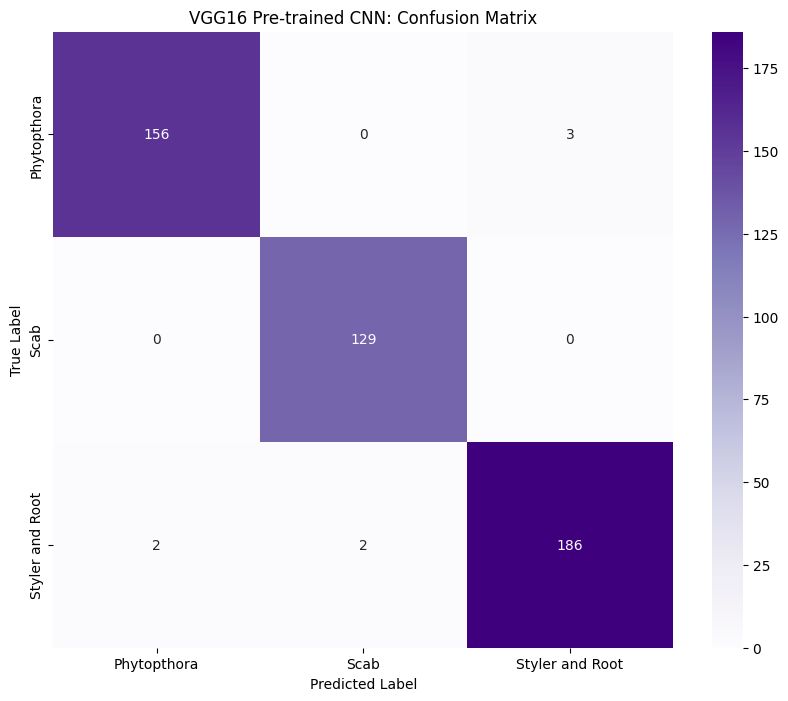


CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Phytopthora       0.99      0.98      0.98       159
           Scab       0.98      1.00      0.99       129
Styler and Root       0.98      0.98      0.98       190

       accuracy                           0.99       478
      macro avg       0.99      0.99      0.99       478
   weighted avg       0.99      0.99      0.99       478



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Collect all predictions and true labels from the test set
all_preds = []
all_labels = []

model.eval()
print("Generating predictions for VGG16 Confusion Matrix...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Define your class names
class_names = ['Phytopthora', 'Scab', 'Styler and Root']

# 3. Create the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('VGG16 Pre-trained CNN: Confusion Matrix')
plt.show()

# 5. Classification Report (Precision, Recall, F1-Score)
print("\n" + "="*30)
print("CLASSIFICATION REPORT")
print("="*30)
print(classification_report(all_labels, all_preds, target_names=class_names))

Calculating probabilities for VGG16 ROC Curve...


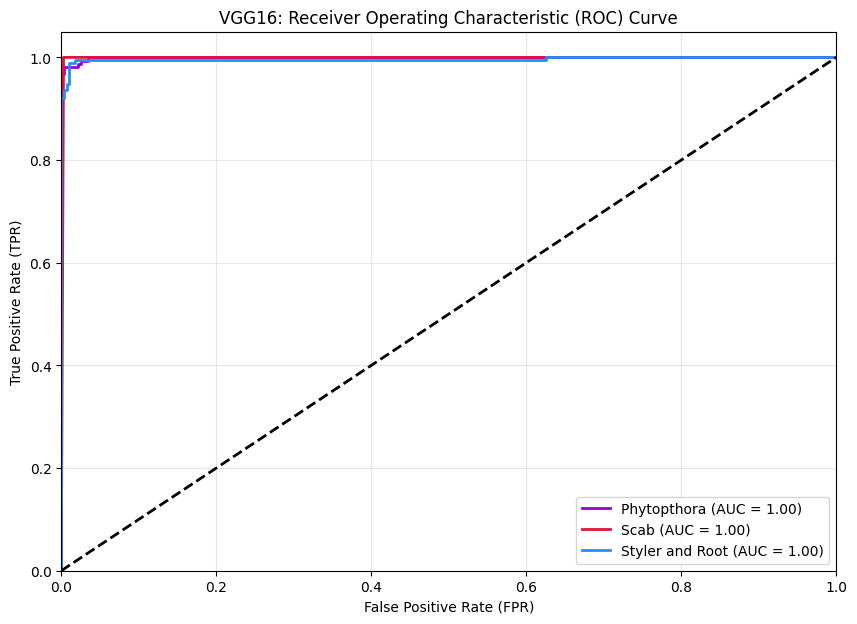

In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predicted probabilities from the model
model.eval()
all_probs = []
all_labels = []

print("Calculating probabilities for VGG16 ROC Curve...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        # Softmax converts raw output to probabilities for each class
        probs = torch.nn.functional.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# 2. Binarize labels for 3-class ROC (One-vs-Rest)
n_classes = 3
bin_labels = label_binarize(all_labels, classes=[0, 1, 2])
class_names = ['Phytopthora', 'Scab', 'Styler and Root']

# 3. Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(bin_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the Curves
plt.figure(figsize=(10, 7))
colors = ['darkviolet', 'crimson', 'dodgerblue']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('VGG16: Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()